# Task 2: Feature Scaling and Model Comparison

## California Housing Dataset

Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

Step 2: Load the Dataset

The California Housing Dataset is loaded from Scikit-Learn. This dataset contains housing-related features and median house values.

In [47]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


Step 3: Data Inspection

The dataset is converted into a Pandas DataFrame for easier analysis and inspection of features.

In [48]:
df = pd.DataFrame(X, columns=housing.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Step 4: Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate performance.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (16512, 8)
Testing Set: (4128, 8)


 Step 5: Feature Scaling

Feature Scaling is performed using StandardScaler. This ensures that all features are on a similar scale, which helps improve the performance of regression models.

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


 Step 6: Linear Regression Model

A Linear Regression model is trained using the scaled training data and evaluated using RMSE and R² Score.

In [51]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [52]:
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
RMSE: 0.7455813830127763
R² Score: 0.575787706032451


 Step 7: Ridge Regression Model

A Ridge Regression model is trained to reduce overfitting by applying regularization. The model is evaluated using RMSE and R² Score.

In [53]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [54]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("RMSE:", rmse_ridge)
print("R² Score:", r2_ridge)

Ridge Regression Results
RMSE: 0.7455567442814778
R² Score: 0.5758157428913686


 Step 8: Decision Tree Regressor

A Decision Tree Regressor is trained and evaluated. Decision Trees can capture non-linear relationships in the dataset.

In [55]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [56]:
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Results
RMSE: 0.7030332265476953
R² Score: 0.622823312540521


 Step 9: Model Evaluation and Comparison

The performance of all models is compared using RMSE and R² Score to identify the best-performing model.

In [57]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [rmse_linear, rmse_ridge, rmse_tree],
    "R2 Score": [r2_linear, r2_ridge, r2_tree]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.703033,0.622823


In [58]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Decision Tree
RMSE             0.703033
R2 Score         0.622823
Name: 2, dtype: object


 Step 10: Actual vs Predicted Visualization

A scatter plot is generated to compare actual house prices with predicted house prices. The red diagonal line represents perfect predictions. Points closer to this line indicate better model performance.

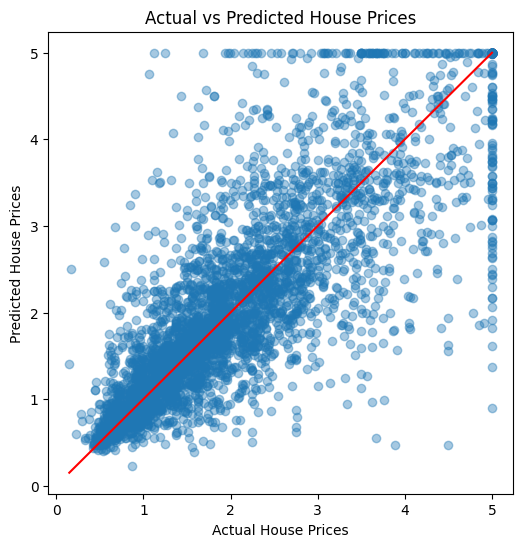

In [59]:
best_model = DecisionTreeRegressor(random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

 Step 11: Performance Comparison Chart

A bar chart is created to compare the performance of Linear Regression, Ridge Regression, and Decision Tree Regressor using RMSE and R² Score.

This visualization helps identify the best-performing model based on evaluation metrics.

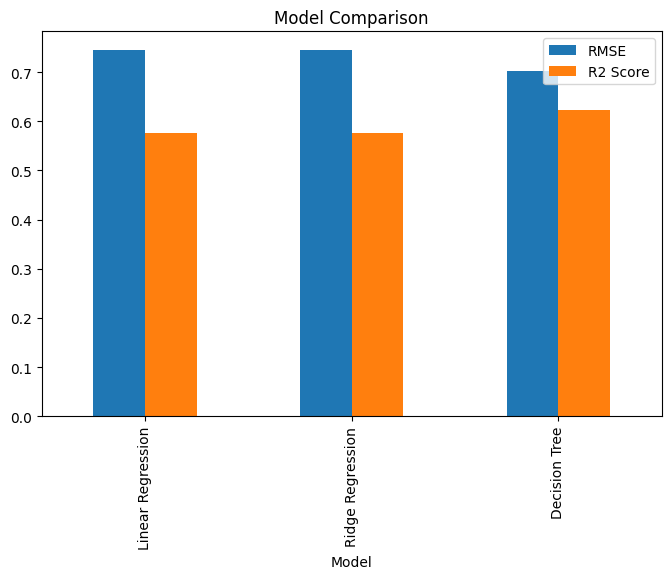

In [60]:
results.plot(
    x="Model",
    y=["RMSE", "R2 Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.show()

## Observation

- Decision Tree Regressor achieved the highest R² Score.
- Decision Tree Regressor achieved the lowest RMSE value.
- Linear Regression and Ridge Regression showed similar performance.
- Based on the evaluation metrics, Decision Tree Regressor outperformed the other models.

## Conclusion

In this task, three regression models were trained and evaluated on the California Housing Dataset:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

Feature scaling was applied using StandardScaler for Linear Regression and Ridge Regression models.

The models were evaluated using RMSE and R² Score. Among the three models, the Decision Tree Regressor achieved the best performance with the lowest RMSE and highest R² Score.

Therefore, Decision Tree Regressor was selected as the best model for predicting house prices in this dataset.

Future improvements can include Random Forest, Gradient Boosting, and Hyperparameter Tuning to further improve prediction accuracy.